<a href="https://colab.research.google.com/github/qmbasheer/GenAI/blob/main/GenAI_Programs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0694 - val_loss: 0.0400
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0344 - val_loss: 0.0292
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0263 - val_loss: 0.0231
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0215 - val_loss: 0.0194
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0183 - val_loss: 0.0166
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


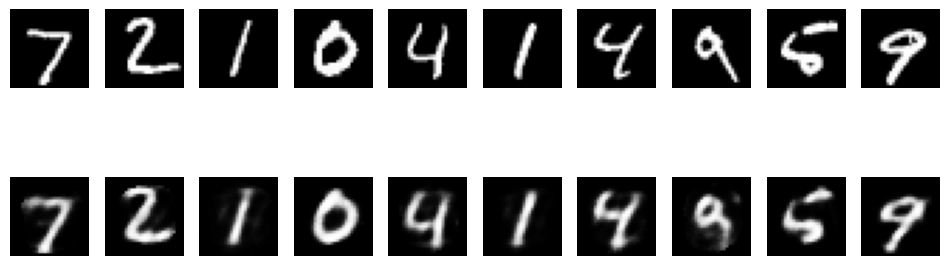

In [ ]:
#Program 1 - Autoencoder implementation for image reconstruction.
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Load MNIST dataset (handwritten digits)
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images to vectors of size 784 (28x28)
x_train = x_train.reshape((len(x_train), 28*28))
x_test = x_test.reshape((len(x_test), 28*28))

# 2. Build Autoencoder
input_img = layers.Input(shape=(784,))
encoded = layers.Dense(32, activation="relu")(input_img)   # Encoder
decoded = layers.Dense(784, activation="sigmoid")(encoded) # Decoder

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer="adam", loss="mse")

# 3. Train Autoencoder
autoencoder.fit(x_train, x_train,
                epochs=5,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# 4. Test Reconstruction
decoded_imgs = autoencoder.predict(x_test[:10])

# Plot original vs reconstructed
plt.figure(figsize=(12, 4))
for i in range(10):
    # Original
    ax = plt.subplot(2, 10, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    # Reconstructed
    ax = plt.subplot(2, 10, i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.axis("off")
plt.show()


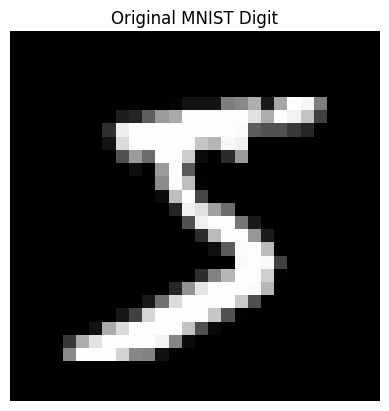

Epoch 1, Loss: 27.2389
Epoch 2, Loss: 26.2735
Epoch 3, Loss: 25.6128
Epoch 4, Loss: 25.1537
Epoch 5, Loss: 24.9294


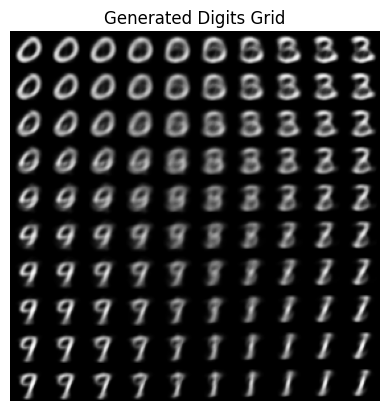

In [ ]:
#Program 2 - Variational Autoencoder (VAE) for MNIST digit generation.
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Load MNIST
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Show one original image
plt.imshow(x_train[0].reshape(28,28), cmap="gray")
plt.title("Original MNIST Digit")
plt.axis("off")
plt.show()

latent_dim = 2

# 2. Encoder model
encoder_inputs = tf.keras.Input(shape=(784,))
h = tf.keras.layers.Dense(128, activation="relu")(encoder_inputs)
z_mean = tf.keras.layers.Dense(latent_dim)(h)
z_log_var = tf.keras.layers.Dense(latent_dim)(h)
encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var])

# 3. Decoder model
decoder_inputs = tf.keras.Input(shape=(latent_dim,))
h_dec = tf.keras.layers.Dense(128, activation="relu")(decoder_inputs)
decoder_outputs = tf.keras.layers.Dense(784, activation="sigmoid")(h_dec)
decoder = tf.keras.Model(decoder_inputs, decoder_outputs)

optimizer = tf.keras.optimizers.Adam()

# 4. Training loop
batch_size = 256
epochs = 5
for epoch in range(epochs):
    for i in range(0, len(x_train), batch_size):
        x_batch = x_train[i:i+batch_size]
        with tf.GradientTape() as tape:
            zm, zl = encoder(x_batch)
            eps = tf.random.normal(tf.shape(zm))
            z = zm + tf.exp(0.5 * zl) * eps
            recon = decoder(z)

            # Reconstruction loss
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(x_batch, recon), axis=-1)
            )
            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + zl - tf.square(zm) - tf.exp(zl), axis=-1)
            )
            total_loss = recon_loss + kl_loss
        grads = tape.gradient(total_loss, encoder.trainable_weights + decoder.trainable_weights)
        optimizer.apply_gradients(zip(grads, encoder.trainable_weights + decoder.trainable_weights))
    print(f"Epoch {epoch+1}, Loss: {total_loss.numpy():.4f}")

# 5. Generate digits from latent grid
grid_x, grid_y = np.linspace(-2, 2, 10), np.linspace(-2, 2, 10)
figure = np.zeros((28*10, 28*10))
for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        d = decoder(np.array([[xi, yi]])).numpy().reshape(28,28)
        figure[i*28:(i+1)*28, j*28:(j+1)*28] = d

plt.imshow(figure, cmap="gray")
plt.title("Generated Digits Grid")
plt.axis("off")
plt.show()


In [ ]:
#program 3 - Prompt Engineering basics — explicit vs implicit prompts,
# Prompt Engineering Basics Demo
from transformers import pipeline

# Load a small model for quick demo
generator = pipeline("text-generation", model="gpt2")

# --- Explicit vs Implicit ---
explicit_prompt = "Summarize the story of Cinderella in 3 bullet points."
implicit_prompt = "Alice: Hi Bob, how are you?\nBob:"

print("\n--- Explicit Prompt ---")
print(generator(explicit_prompt, max_length=50, num_return_sequences=1)[0]['generated_text'])

print("\n--- Implicit Prompt ---")
print(generator(implicit_prompt, max_length=50, num_return_sequences=1)[0]['generated_text'])

# --- Zero-Shot vs Few-Shot ---
zero_shot_prompt = "Translate 'Good morning' into French."
few_shot_prompt = """Translate the following English phrases into French:
1. Hello → Bonjour
2. Thank you → Merci
3. Good morning →"""

print("\n--- Zero-Shot Prompt ---")
print(generator(zero_shot_prompt, max_length=50, num_return_sequences=1)[0]['generated_text'])

print("\n--- Few-Shot Prompt ---")
print(generator(few_shot_prompt, max_length=50, num_return_sequences=1)[0]['generated_text'])
